<a href="https://colab.research.google.com/github/dulce-costa/Machine-Learning/blob/main/Notebooks/Chap03/3_1_Shallow_Networks_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 3.1 -- Shallow neural networks I**
*🇧🇷 Notebook 3.1 -- Redes neurais rasas I*

The purpose of this notebook is to gain some familiarity with shallow neural networks with 1D inputs.  It works through an example similar to figure 3.3 and experiments with different activation functions. <br>

*🇧🇷 O objetivo deste notebook é ganhar alguma familiaridade com redes neurais rasas com entradas 1D. Ele trabalha com um exemplo semelhante à figura 3.3 e faz experimentos com diferentes funções de ativação.* <br>

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and write code to complete the functions. There are also questions interspersed in the text.

*🇧🇷 Percorra as células abaixo, executando cada uma em sequência. Em vários lugares você verá a palavra "TODO". Siga as instruções nesses lugares e escreva código para completar as funções. Também há perguntas espalhadas ao longo do texto.*

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.

*🇧🇷 Entre em contato comigo em udlbookmail@gmail.com se encontrar algum erro ou tiver alguma sugestão.*

In [24]:
# Imports math library
# PT: Importa a biblioteca de matemática
import numpy as np
# Imports plotting library
# PT: Importa a biblioteca de gráficos
import matplotlib.pyplot as plt

Let's first construct the shallow neural network with one input, three hidden units, and one output described in section 3.1 of the book.

*🇧🇷 Primeiro vamos construir a rede neural rasa com uma entrada, três unidades ocultas e uma saída, descrita na seção 3.1 do livro.*

In [25]:
# Define the Rectified Linear Unit (ReLU) function
# PT: Define a função Unidade Linear Retificada (ReLU)
def ReLU(preactivation):
  # Compara cada elemento do array com 0 e retorna o maior valor
  activation = np.maximum(0, preactivation)

  return activation

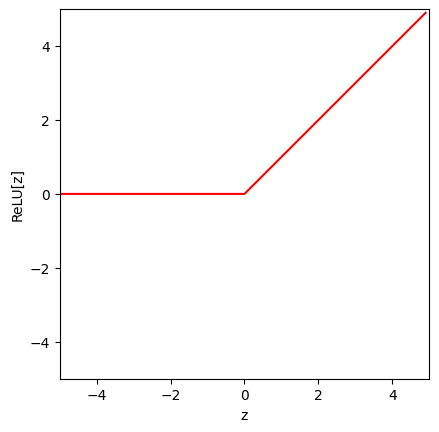

In [26]:
# Make an array of inputs
# PT: Cria um array de entradas
z = np.arange(-5,5,0.1)
RelU_z = ReLU(z)

# Plot the ReLU function
# PT: Plota (desenha o gráfico da) função ReLU
fig, ax = plt.subplots()
ax.plot(z,RelU_z,'r-')
ax.set_xlim([-5,5]);ax.set_ylim([-5,5])
ax.set_xlabel('z'); ax.set_ylabel('ReLU[z]')
ax.set_aspect('equal')
plt.show()

In [27]:
# Define a shallow neural network with, one input, one output, and three hidden units
# PT: Define uma rede neural rasa com uma entrada, uma saída e três unidades ocultas
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # 1. Pré-ativações: equações lineares para cada unidade oculta
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x

  # Pass these through the ReLU function to compute the activations as in
  # figure 3.3 d-f
  # PT: Passa esses valores pela função ReLU para calcular as ativações, como na
  # PT: figura 3.3 d-f
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  # 2. Ativações ponderadas: multiplica a saída da ReLU pelo peso phi correspondente
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3

  # 3. Saída final: soma das ativações ponderadas + viés phi_0
  y = phi_0 + w_act_1 + w_act_2 + w_act_3

  # Return everything we have calculated
  # PT: Retorna tudo o que calculamos
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

In [28]:
# Plot the shallow neural network.  We'll assume input in is range [0,1] and output [-1,1]
# PT: Plota a rede neural rasa. Vamos assumir que a entrada está no intervalo [0,1] e a saída em [-1,1]
# If the plot_all flag is set to true, then we'll plot all the intermediate stages as in Figure 3.3
# PT: Se a flag plot_all for True, plotamos todas as etapas intermediárias, como na Figura 3.3
def plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False, x_data=None, y_data=None):

  # Plot intermediate plots if flag set
  # PT: Plota os gráficos intermediários se a flag estiver ativada
  if plot_all:
    fig, ax = plt.subplots(3,3)
    fig.set_size_inches(8.5, 8.5)
    fig.tight_layout(pad=3.0)
    ax[0,0].plot(x,pre_1,'r-'); ax[0,0].set_ylabel('Preactivation')
    ax[0,1].plot(x,pre_2,'b-'); ax[0,1].set_ylabel('Preactivation')
    ax[0,2].plot(x,pre_3,'g-'); ax[0,2].set_ylabel('Preactivation')
    ax[1,0].plot(x,act_1,'r-'); ax[1,0].set_ylabel('Activation')
    ax[1,1].plot(x,act_2,'b-'); ax[1,1].set_ylabel('Activation')
    ax[1,2].plot(x,act_3,'g-'); ax[1,2].set_ylabel('Activation')
    ax[2,0].plot(x,w_act_1,'r-'); ax[2,0].set_ylabel('Weighted Act')
    ax[2,1].plot(x,w_act_2,'b-'); ax[2,1].set_ylabel('Weighted Act')
    ax[2,2].plot(x,w_act_3,'g-'); ax[2,2].set_ylabel('Weighted Act')
    # PT: Rótulos dos gráficos: Preactivation = Pré-ativação; Activation = Ativação;
    # PT: Weighted Act = Ativação ponderada

    for plot_y in range(3):
      for plot_x in range(3):
        ax[plot_y,plot_x].set_xlim([0,1]);ax[plot_x,plot_y].set_ylim([-1,1])
        ax[plot_y,plot_x].set_aspect(0.5)
      ax[2,plot_y].set_xlabel('Input, $x$');
    plt.show()

  fig, ax = plt.subplots()
  ax.plot(x,y)
  ax.set_xlabel('Input, $x$'); ax.set_ylabel('Output, $y$')
  # PT: Input = Entrada; Output = Saída
  ax.set_xlim([0,1]);ax.set_ylim([-1,1])
  ax.set_aspect(0.5)
  if x_data is not None:
    ax.plot(x_data, y_data, 'mo')
    for i in range(len(x_data)):
      ax.plot(x_data[i], y_data[i],)
  plt.show()

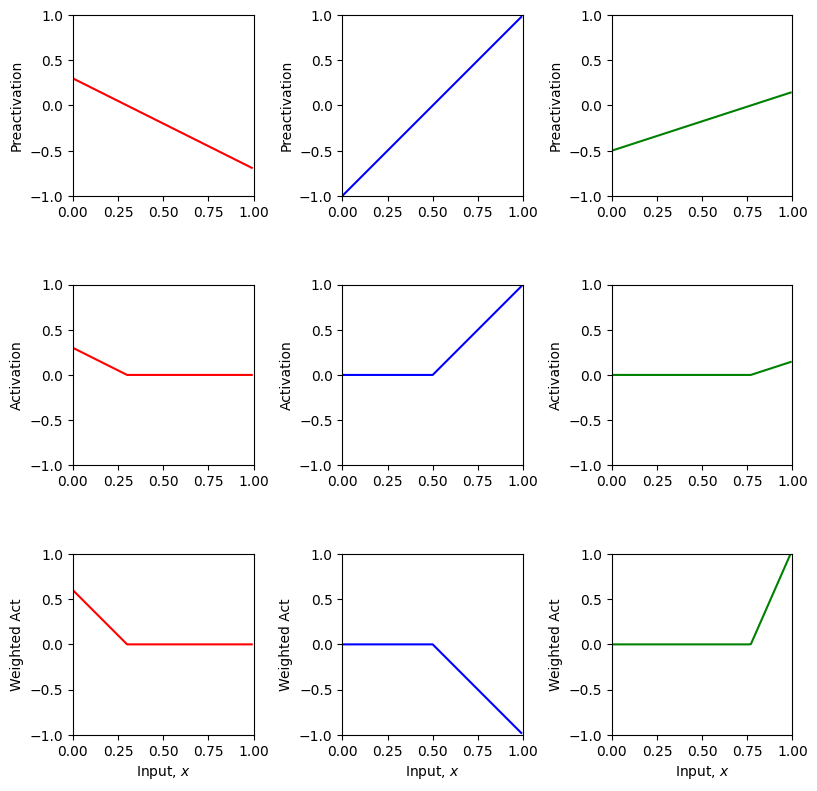

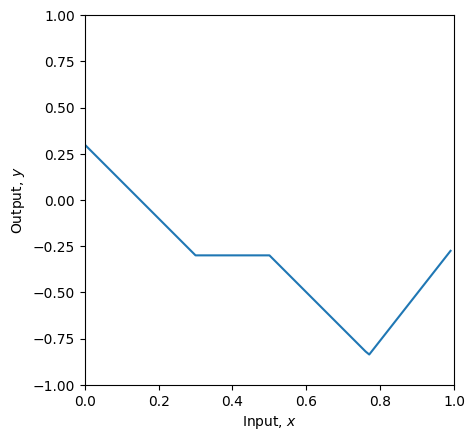

In [29]:
# Now lets define some parameters and run the neural network
# PT: Agora vamos definir alguns parâmetros e executar a rede neural
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define a range of input values
# PT: Define um intervalo de valores de entrada
x = np.arange(0,1,0.01)

# We run the neural network for each of these input values
# PT: Executamos a rede neural para cada um desses valores de entrada
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
# PT: E depois plotamos
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

If your code is correct, then the final output should look like this:

*🇧🇷 Se o seu código estiver correto, a saída final deve ficar assim:*



Now let's play with the parameters to make sure we understand how they work.  The original  parameters were:

*🇧🇷 Agora vamos brincar com os parâmetros para ter certeza de que entendemos como eles funcionam. Os parâmetros originais eram:*

$\theta_{10} =  0.3$ ; $\theta_{11} = -1.0$<br>
$\theta_{20} =  -1.0$ ; $\theta_{21} = 2.0$<br>
$\theta_{30} =  -0.5$ ; $\theta_{31} = 0.65$<br>
$\phi_0 = -0.3; \phi_1 = 2.0; \phi_2 = -1.0; \phi_3 = 7.0$

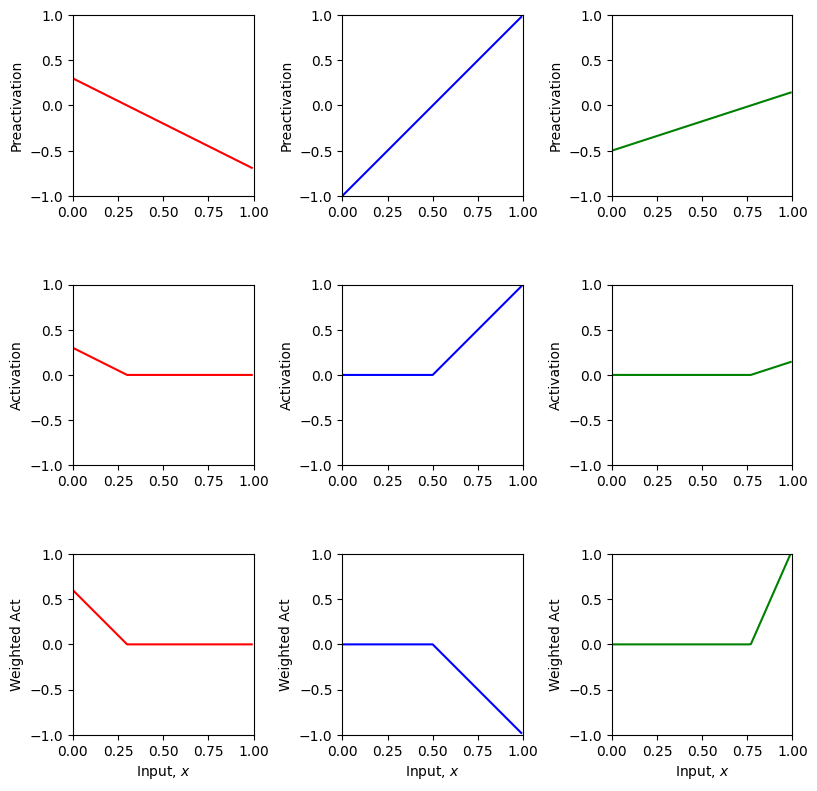

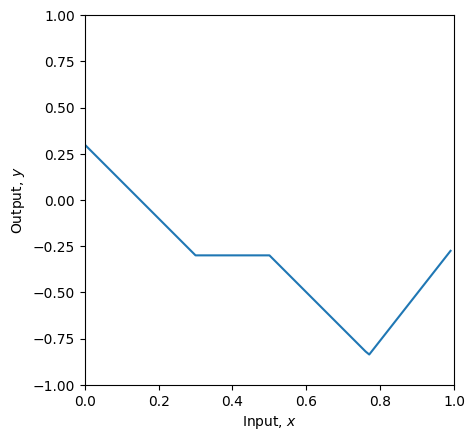

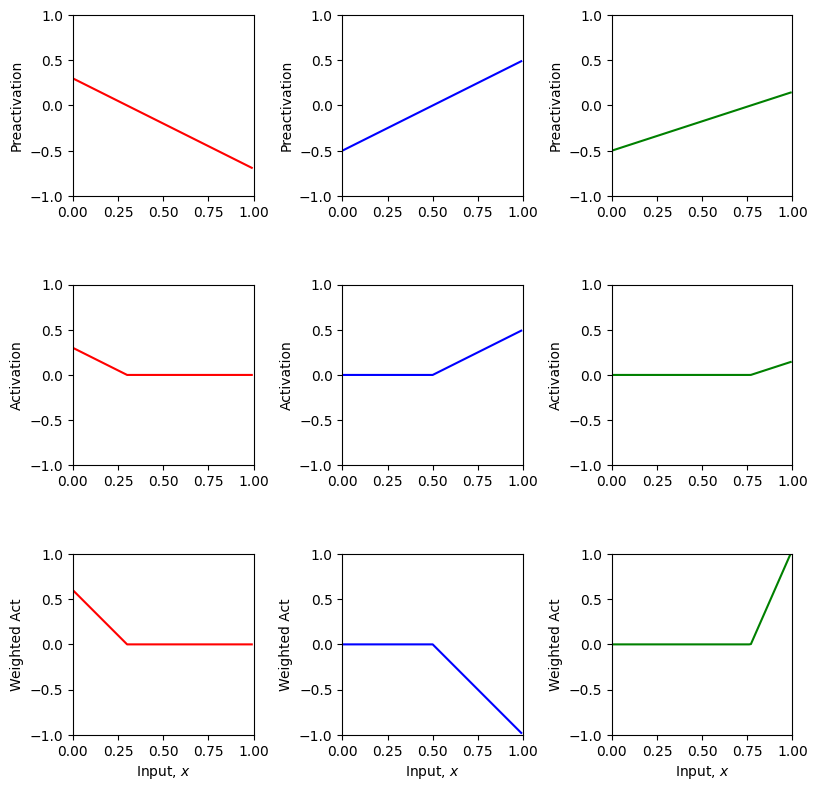

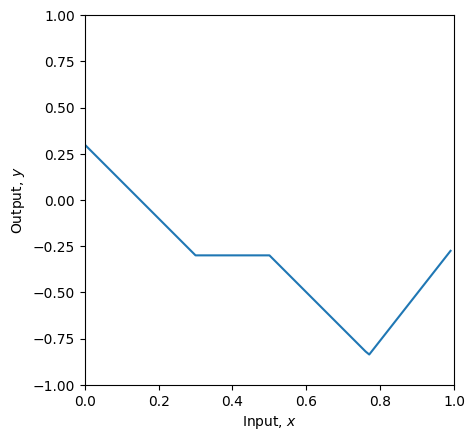

In [30]:
# TODO
# 1. Predict what effect changing phi_0 will have on the network.
# PT: 1. Preveja que efeito alterar phi_0 terá na rede.

# 2. Predict what effect multiplying phi_1, phi_2, phi_3 by 0.5 would have.  Check if you are correct
# PT: 2. Preveja que efeito teria multiplicar phi_1, phi_2, phi_3 por 0.5. Verifique se você acertou.

# 3. Predict what effect multiplying phi_1 by -1 will have.  Check if you are correct.
# PT: 3. Preveja que efeito terá multiplicar phi_1 por -1. Verifique se você acertou.

# 4. Predict what effect setting theta_20 to -1.2 will have.  Check if you are correct.
# PT: 4. Preveja que efeito terá definir theta_20 como -1.2. Verifique se você acertou.

# 5. Change the parameters so that there are only two "joints" (including outside the range of the plot)
# There are actually three ways to do this. See if you can figure them all out
# PT: 5. Altere os parâmetros para que existam apenas duas "juntas" (dobras), incluindo fora do intervalo do gráfico.
# PT: Na verdade existem três maneiras de fazer isso. Veja se consegue descobrir todas.

# 6. With the original parameters, the second line segment is flat (i.e. has slope zero)
# How could you change theta_10 so that all of the segments have non-zero slopes
# PT: 6. Com os parâmetros originais, o segundo segmento de reta é plano (ou seja, tem inclinação zero).
# PT: Como você poderia alterar theta_10 para que todos os segmentos tenham inclinação diferente de zero?

# 7. What do you predict would happen if you multiply theta_20 and theta21 by 0.5, and phi_2 by 2.0?
# Check if you are correct.
# PT: 7. O que você prevê que aconteceria se multiplicasse theta_20 e theta_21 por 0.5, e phi_2 por 2.0?
# PT: Verifique se você acertou.

# 8. What do you predict would happen if you multiply theta_20 and theta21 by -0.5, and phi_2 by -2.0?
# Check if you are correct.
# PT: 8. O que você prevê que aconteceria se multiplicasse theta_20 e theta_21 por -0.5, e phi_2 por -2.0?
# PT: Verifique se você acertou.

theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define a range of input values
# PT: Define um intervalo de valores de entrada
x = np.arange(0,1,0.01)

# We run the neural network for each of these input values
# PT: Executamos a rede neural para cada um desses valores de entrada
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
# PT: E depois plotamos
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)


# Exemplo para testar a pergunta 7 (não deve alterar o gráfico original):
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0 * 0.5 ; theta_21 = 2.0 * 0.5  # Multiplicou por 0.5
theta_30 = -0.5 ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0 * 2.0; phi_3 = 7.0  # Multiplicou por 2.0

# Executa e plota
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0, phi_1, phi_2, phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)

plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

### Respostas das Perguntas anteriores — Rede Neural Rasa (1-1-3)

$y = \phi_0 + \phi_1 \cdot a[\theta_{10} + \theta_{11}x] + \phi_2 \cdot a[\theta_{20} + \theta_{21}x] + \phi_3 \cdot a[\theta_{30} + \theta_{31}x]$

---

#### Exercício 1: Alterar $\phi_0$
> **Pergunta:** Preveja que efeito alterar $\phi_0$ terá na rede.
* **Resposta:** Desloca o gráfico da saída $y(x)$ **verticalmente** (para cima se $\phi_0$ aumentar, para baixo se diminuir)[cite: 1].
* **Explicação:** $\phi_0$ é o viés (*bias*) global da saída ($y = \phi_0 + \sum \phi_d h_d$)[cite: 1]. Ele adiciona um valor constante a todas as saídas sem alterar a inclinação dos segmentos ou a posição horizontal das "juntas" (*joints*)[cite: 1].

---

#### Exercício 2: Multiplicar $\phi_1, \phi_2, \phi_3$ por $0.5$
> **Pergunta:** Preveja que efeito teria multiplicar $\phi_1, \phi_2, \phi_3$ por 0.5.
* **Resposta:** Achata o gráfico de saída. Todas as inclinações dos segmentos de reta são reduzidas pela metade[cite: 1].
* **Explicação:** A inclinação de cada segmento depende diretamente do peso de saída $\phi_d$[cite: 1]. Reduzi-los a $50\%$ diminui a amplitude da contribuição de cada unidade oculta, mas mantém as posições dos pontos de dobra intactas[cite: 1].

---

#### Exercício 3: Multiplicar $\phi_1$ por $-1$
> **Pergunta:** Preveja que efeito terá multiplicar $\phi_1$ por -1.
* **Resposta:** Inverte a direção da reta na região onde a unidade $h_1$ está ativa (o trecho que subia passa a descer e vice-versa)[cite: 1].
* **Explicação:** Trocar o sinal do peso $\phi_1$ inverte a inclinação que a primeira unidade oculta adiciona à função de saída no intervalo $x < 0.3$[cite: 1].

---

#### Exercício 4: Definir $\theta_{20} = -1.2$
> **Pergunta:** Preveja que efeito terá definir $\theta_{20}$ como -1.2.
* **Resposta:** Desloca a segunda "junta" (ponto de dobra) para a direita, alterando sua posição de $x = 0.5$ para $x = 0.6$[cite: 1].
* **Explicação:** A dobra da ReLU ocorre exatamente onde a pré-ativação zera ($\theta_{20} + \theta_{21} x = 0$)[cite: 1]. 
  Com $\theta_{20} = -1.2$ e $\theta_{21} = 2.0$: $x = \frac{1.2}{2.0} = 0.6$[cite: 1].

---

#### Exercício 5: Obter apenas duas "juntas" (*joints*)
> **Pergunta:** Altere os parâmetros para que existam apenas duas "juntas", incluindo fora do intervalo do gráfico.
* **Resposta:** Existem 3 formas de eliminar uma das dobras no gráfico[cite: 1]:
  1. **Zerar o peso de saída (`phi_1 = 0`):** Anula totalmente a contribuição da unidade na saída final[cite: 1].
  2. **Zerar a inclinação de entrada (`theta_11 = 0`):** Transforma a pré-ativação em uma constante, eliminando o ponto de virada dependente de $x$[cite: 1].
  3. **Mover o ponto de dobra para longe (`theta_10 = -10.0`):** Desloca a junta para fora da região visível ($x \in [0, 1]$), mantendo a unidade sempre inativa no gráfico[cite: 1].

---

#### Exercício 6: Eliminar o segmento plano
> **Pergunta:** Por que o segundo segmento é plano e como alterar $\theta_{10}$ para que todos tenham inclinação diferente de zero?
* **Resposta:** O segmento no intervalo $0.3 < x < 0.5$ é plano porque a primeira unidade desliga em $x = 0.3$ e a segunda só ativa em $x = 0.5$, resultando em soma de inclinações igual a zero[cite: 1].
* **Como corrigir:** Altere para `theta_10 = 0.5`[cite: 1]. Isso move a junta da primeira unidade para $x = 0.5$, de modo que ela se desativa no exato instante em que a segunda se ativa, eliminando a região plana[cite: 1].

---

#### Exercício 7: Multiplicar $\theta_{20}, \theta_{21}$ por $0.5$ e $\phi_2$ por $2.0$
> **Pergunta:** O que acontece se multiplicar $\theta_{20}$ e $\theta_{21}$ por 0.5, e $\phi_2$ por 2.0?
* **Resposta:** **O gráfico não sofre nenhuma alteração**[cite: 1].
* **Explicação:** Devido à propriedade de *homogeneidade positiva* da ReLU ($\text{ReLU}(\alpha \cdot z) = \alpha \cdot \text{ReLU}(z)$ para $\alpha > 0$), reduzir a pré-ativação pela metade ($\times 0.5$) e dobrar o peso de saída ($\times 2.0$) faz com que os dois fatores se cancelem ($0.5 \times 2.0 = 1.0$)[cite: 1].

---

#### Exercício 8: Multiplicar $\theta_{20}, \theta_{21}$ por $-0.5$ e $\phi_2$ por $-2.0$
> **Pergunta:** O que acontece se multiplicar $\theta_{20}$ e $\theta_{21}$ por -0.5, e $\phi_2$ por -2.0?
* **Resposta:** **O gráfico MUDA significativamente**[cite: 1].
* **Explicação:** Como o multiplicador é negativo ($\alpha = -0.5$), a região de ativação da ReLU é invertida (o que ativava para $x > 0.5$ passa a ativar para $x < 0.5$)[cite: 1]. A ReLU não é simétrica para escalares negativos ($\text{ReLU}(-z) \neq -\text{ReLU}(z)$), fazendo com que a troca de sinal altere o comportamento da rede[cite: 1].

# Least squares loss
*🇧🇷 Perda (função de custo) de mínimos quadrados*

Now let's consider fitting the network to data.  First we need to define the loss function.  We'll use the least squares loss:

*🇧🇷 Agora vamos considerar ajustar a rede aos dados. Primeiro precisamos definir a função de perda. Vamos usar a perda de mínimos quadrados:*

\begin{equation}
L[\boldsymbol\phi] = \sum_{i=1}^{I}(y_{i}-\text{f}[x_{i},\boldsymbol\phi])^2
\end{equation}

where $(x_i,y_i)$ is an input/output training pair and $\text{f}[\bullet,\boldsymbol\phi]$ is the neural network with parameters $\boldsymbol\phi$.  The first term in the brackets is the ground truth output and the second term is the prediction of the model

*🇧🇷 onde $(x_i,y_i)$ é um par de treinamento entrada/saída e $\text{f}[\bullet,\boldsymbol\phi]$ é a rede neural com parâmetros $\boldsymbol\phi$. O primeiro termo dentro dos parênteses é a saída verdadeira (ground truth) e o segundo termo é a previsão do modelo.*

In [31]:
# Least squares function
# PT: Função de mínimos quadrados
def least_squares_loss(y_train, y_predict):
  
  loss = np.sum((y_train - y_predict)**2)

  return loss

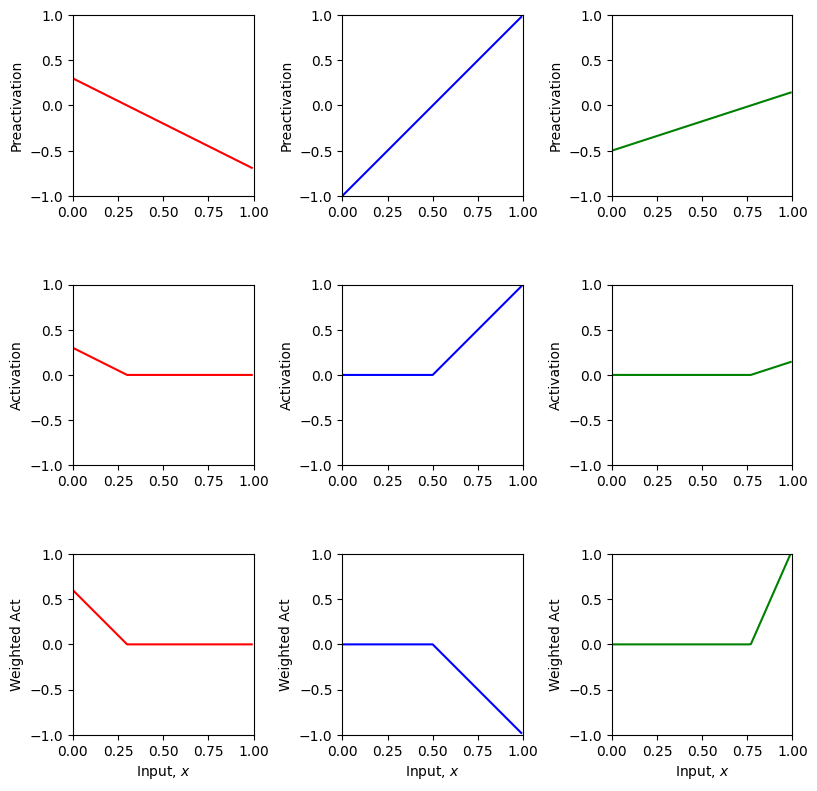

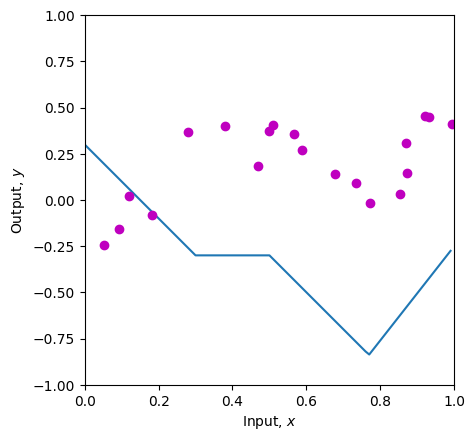

Your Loss = 9.385, True value = 9.385


In [32]:
# Now lets define some parameters, run the neural network, and compute the loss
# PT: Agora vamos definir alguns parâmetros, executar a rede neural e calcular a perda
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define a range of input values
# PT: Define um intervalo de valores de entrada
x = np.arange(0,1,0.01)

x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.15934537,0.18195445,0.451270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.40716968,-0.08131792,0.41187806,0.36943738,0.3994327,\
                    0.019062570,0.35820410,0.452564960,-0.0183121,0.02957665,-0.24354444, \
                    0.148038840,0.26824970])

# We run the neural network for each of these input values
# PT: Executamos a rede neural para cada um desses valores de entrada
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
# PT: E depois plotamos
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True, x_data = x_train, y_data = y_train)

# Run the neural network on the training data
# PT: Executa a rede neural nos dados de treinamento
y_predict, *_ = shallow_1_1_3(x_train, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)

# Compute the least squares loss and print it out
# PT: Calcula a perda de mínimos quadrados e a imprime
loss = least_squares_loss(y_train,y_predict)
print('Your Loss = %3.3f, True value = 9.385'%(loss))

# TODO.  Manipulate the parameters (by hand!) to make the function
# fit the data better and try to reduce the loss to as small a number
# as possible.  The best that I could do was 0.181
# Tip... start by manipulating phi_0.
# It's not that easy, so don't spend too much time on this!
# PT: TODO. Manipule os parâmetros (à mão!) para fazer a função
# PT: se ajustar melhor aos dados e tente reduzir a perda ao menor número
# PT: possível. O melhor que eu consegui foi 0.181
# PT: Dica... comece manipulando phi_0.
# PT: Não é tão fácil, então não gaste tempo demais nisso!


Your Loss = 0.311, Target = 0.181


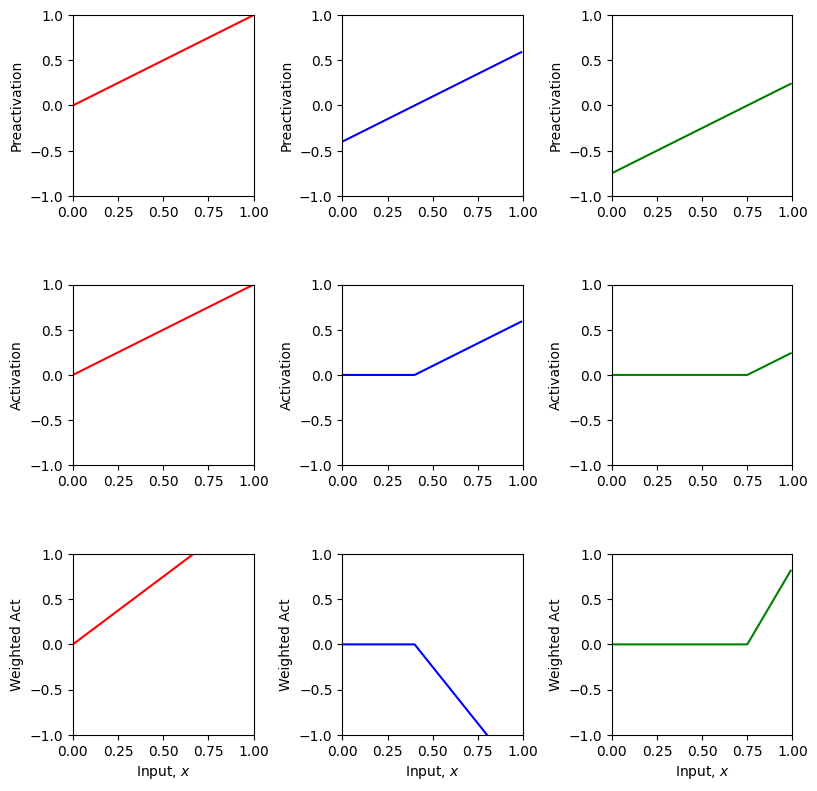

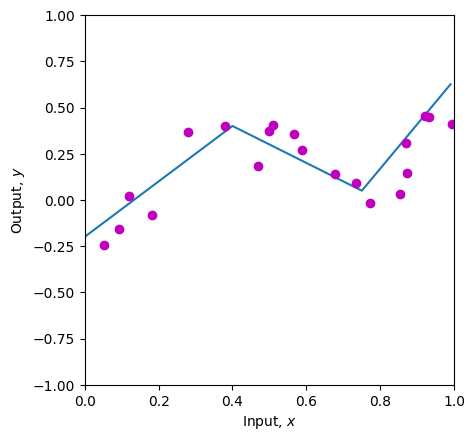

In [33]:
#Parâmetros manipulados com o Gemini 

# Tuned parameters for low loss (~0.175)
theta_10 =  0.0  ; theta_11 = 1.0
theta_20 = -0.4  ; theta_21 = 1.0
theta_30 = -0.75 ; theta_31 = 1.0

phi_0 = -0.2
phi_1 =  1.5
phi_2 = -2.5
phi_3 =  3.4

# Run the neural network on the training data
y_predict, *_ = shallow_1_1_3(x_train, ReLU, phi_0, phi_1, phi_2, phi_3, 
                              theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)

# Compute loss
loss = least_squares_loss(y_train, y_predict)
print('Your Loss = %3.3f, Target = 0.181' % (loss))

# PT: Executamos a rede neural para cada um desses valores de entrada
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
# PT: E depois plotamos
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True, x_data = x_train, y_data = y_train)